# Modelización predictiva — Predicción de éxito musical

Construimos un modelo de **regresión logística** para predecir si una canción será un éxito a partir de sus características de audio y de algunas variables derivadas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                             precision_score, recall_score, accuracy_score)

## Carga del dataset

In [2]:
data = pd.read_parquet('spotify_dataset_7_clus.parquet')

In [92]:
data

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,valence,tempo,time_signature,track_genre,exito_musical,track_genre_encoded,n_artistas,energia_bailable,cluster,cluster_nombre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,0.024289,0,0.628394,-0.721328,1,...,0.928983,-1.142994,4,acoustic,1,0,1,0.311636,4,Pop y Dance
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,-0.737425,0,-0.847891,-1.896382,1,...,-0.799395,-1.490909,4,acoustic,0,0,1,0.069720,6,Acústicas y Folk
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,-0.162155,0,-0.744089,-1.127618,0,...,-1.366520,-1.529510,4,acoustic,0,0,2,0.157242,6,Acústicas y Folk
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,-0.245726,0,-1.735968,-2.320198,0,...,-1.277786,1.987276,3,acoustic,1,0,1,0.015854,6,Acústicas y Folk
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,-0.274670,0,0.293923,-0.793026,2,...,-1.185194,-0.074292,4,acoustic,1,0,1,0.273774,6,Acústicas y Folk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113544,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,1.474615,0,-2.278041,-1.621539,5,...,-1.698692,0.127424,5,world-music,0,113,1,0.040420,0,Ambient
113545,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,1.474624,0,-2.266507,-2.091561,0,...,-1.694449,-1.232341,4,world-music,0,113,1,0.020358,0,Ambient
113546,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,0.407702,0,0.357357,-1.247115,0,...,1.037007,0.340384,4,world-music,0,113,1,0.206941,6,Acústicas y Folk
113547,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,0.524483,0,0.115154,-0.542082,7,...,-0.236129,0.459892,4,world-music,0,113,1,0.297022,6,Acústicas y Folk


## Distrubucion de exito musical


In [3]:
print(f"=== Distribución de exito_musical (umbral popularity >= 70) ===")
print(data['exito_musical'].value_counts())
print()
print(data['exito_musical'].value_counts(normalize=True).mul(100).round(2))

=== Distribución de exito_musical (umbral popularity >= 70) ===
exito_musical
0    108081
1      5468
Name: count, dtype: int64

exito_musical
0    95.18
1     4.82
Name: proportion, dtype: float64


## Selección de variables predictoras

In [4]:

dummies_cluster  = pd.get_dummies(data['cluster_nombre'], prefix='cluster', drop_first=True)
dummies_artistas = pd.get_dummies(data['n_artistas'], prefix='n_artistas', drop_first=True)

cols_modelo = ['danceability', 'energy', 'valence', 'acousticness',
               'instrumentalness', 'speechiness', 'liveness',
               'loudness', 'tempo', 'explicit', 'energia_bailable',
               'duration_ms']

X = pd.concat([
    data[cols_modelo].astype('float64'),
    dummies_cluster.astype('float64'),
    dummies_artistas.astype('float64')
], axis=1)

y = data['exito_musical']

print(f"Matriz de predictores X: {X.shape}")
print(f"Vector objetivo y: {y.shape}")
print(f"\nVariables numéricas:  {len(cols_modelo)}")
print(f"Dummies cluster:      {dummies_cluster.shape[1]}")
print(f"Dummies n_artistas:   {dummies_artistas.shape[1]}")

Matriz de predictores X: (113549, 43)
Vector objetivo y: (113549,)

Variables numéricas:  12
Dummies cluster:      6
Dummies n_artistas:   25


## División train/test y escalado

Dividimos en 70% entrenamiento y 30% test con el método *holdout*, usando `stratify=y` para que la proporción de éxitos sea idéntica en ambas particiones.

Estandarizamos todas las variables con `StandardScaler`. El escalador se **ajusta solo con el train** (`fit_transform` en train, `transform` en test). Si lo ajustáramos con todo el dataset, el test "vería" información de su propia distribución antes de tiempo, lo que se conoce como *data leakage*. Al estandarizar todo a la misma escala (media 0, desviación 1), los coeficientes del modelo serán comparables entre sí.

In [5]:
# ── División 70/30 estratificada ──────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("=== División del dataset ===")
print(f"Train: {X_train.shape[0]} filas ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]} filas ({X_test.shape[0]/len(X)*100:.1f}%)")
print("\n=== Proporción de éxitos en train ===")
print(y_train.value_counts(normalize=True).mul(100).round(2))
print("\n=== Proporción de éxitos en test ===")
print(y_test.value_counts(normalize=True).mul(100).round(2))

=== División del dataset ===
Train: 79484 filas (70.0%)
Test:  34065 filas (30.0%)

=== Proporción de éxitos en train ===
exito_musical
0    95.18
1     4.82
Name: proportion, dtype: float64

=== Proporción de éxitos en test ===
exito_musical
0    95.19
1     4.81
Name: proportion, dtype: float64


In [6]:
# ── Escalado: ajustar SOLO con train para evitar data leakage ──
scaler = StandardScaler()

X_train_esc = scaler.fit_transform(X_train)   # ajusta y transforma con train
X_test_esc  = scaler.transform(X_test)        # solo transforma test

# Reconvertimos a DataFrame para conservar los nombres de columna
X_train_esc = pd.DataFrame(X_train_esc, columns=X_train.columns, index=X_train.index)
X_test_esc  = pd.DataFrame(X_test_esc,  columns=X_train.columns, index=X_test.index)

# Verificación: media ~0 y desviación ~1 en train
print("=== Verificación del escalado (train) ===")
print(X_train_esc.describe().loc[['mean', 'std']].round(3).T)

=== Verificación del escalado (train) ===
                                mean  std
danceability                    -0.0  1.0
energy                          -0.0  1.0
valence                          0.0  1.0
acousticness                    -0.0  1.0
instrumentalness                -0.0  1.0
speechiness                      0.0  1.0
liveness                        -0.0  1.0
loudness                         0.0  1.0
tempo                            0.0  1.0
explicit                        -0.0  1.0
energia_bailable                -0.0  1.0
duration_ms                     -0.0  1.0
cluster_Ambient                  0.0  1.0
cluster_Conciertos y Directos    0.0  1.0
cluster_Instrumental Eléctrico   0.0  1.0
cluster_Pop y Dance             -0.0  1.0
cluster_Rock y Metal             0.0  1.0
cluster_Spoken Word              0.0  1.0
n_artistas_2                     0.0  1.0
n_artistas_3                    -0.0  1.0
n_artistas_4                    -0.0  1.0
n_artistas_5                    -0

## Regresión logística

Entrenamos la regresión logística con `class_weight='balanced'`. Como la clase éxito sigue siendo minoritaria (~5%), este parámetro penaliza más los errores sobre los éxitos, evitando que el modelo aprenda a predecir siempre "fracaso". 

Por defecto, se establece 0.5 como umbral para clasificar éxito o fracaso, pero lo interesante es establecer nosotros ese umbral basándonos en una decisión de negocio.

Umbral alto (ej. 0.8) → se clasifican como éxito las canciones en las que el modelo está muy seguro. Minimiza falsos positivos (no se malgasta inversión en canciones que no van a triunfar), pero se corre el riesgo de perder éxitos reales.
    
Umbral bajo (ej. 0.3) → se clasifica como éxito todo lo que tenga algo de potencial. Se capturan más éxitos reales (mayor recall), pero se invierte  en muchas canciones que no lo serán.

### Entrenamiento del modelo

In [7]:
modelo = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

modelo.fit(X_train_esc, y_train)

# Predicciones sobre el test: probabilidades de éxito para cada canción
y_prob = modelo.predict_proba(X_test_esc)[:, 1]

UMBRAL = 0.5
y_pred = (y_prob >= UMBRAL).astype(int)

print("Modelo entrenado correctamente")
print(f"Predicciones realizadas sobre {len(y_test)} canciones de test")
print(f"Umbral de clasificación aplicado: {UMBRAL}")
print(f"Canciones clasificadas como éxito: {y_pred.sum()} ({y_pred.mean()*100:.1f}%)")

Modelo entrenado correctamente
Predicciones realizadas sobre 34065 canciones de test
Umbral de clasificación aplicado: 0.5
Canciones clasificadas como éxito: 14983 (44.0%)


## Matriz de confusión y métricas

La matriz de confusión muestra los cuatro resultados posibles: verdaderos positivos (éxito acertado), verdaderos negativos (fracaso acertado), falsos positivos (falsa alarma: predijo éxito y era fracaso) y falsos negativos (éxito que se escapó: predijo fracaso y era éxito).

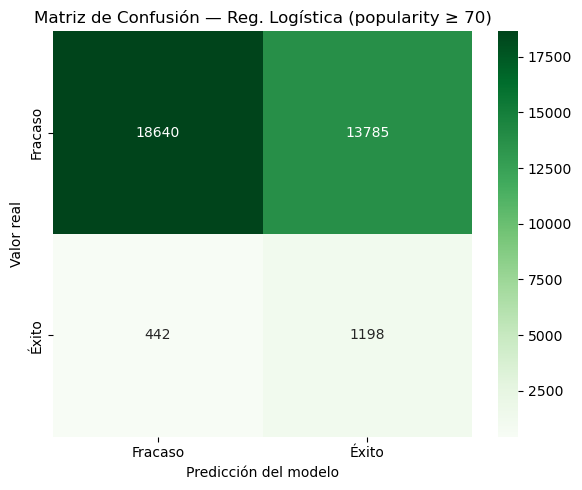

Verdaderos negativos (fracaso acertado): 18640
Falsos positivos (falsa alarma):         13785
Falsos negativos (éxito que se escapó):  442
Verdaderos positivos (éxito acertado):   1198

=== Métricas de evaluación ===
              precision    recall  f1-score   support

     Fracaso       0.98      0.57      0.72     32425
       Éxito       0.08      0.73      0.14      1640

    accuracy                           0.58     34065
   macro avg       0.53      0.65      0.43     34065
weighted avg       0.93      0.58      0.70     34065

Accuracy:  0.5824
AUC-ROC:   0.7052


In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Fracaso', 'Éxito'],
            yticklabels=['Fracaso', 'Éxito'])
plt.title(f'Matriz de Confusión — Reg. Logística (popularity ≥ 70)')
plt.ylabel('Valor real')
plt.xlabel('Predicción del modelo')
plt.tight_layout()
plt.show()

# Desglose explícito de las cuatro casillas
vn, fp, fn, vp = cm.ravel()
print(f"Verdaderos negativos (fracaso acertado): {vn}")
print(f"Falsos positivos (falsa alarma):         {fp}")
print(f"Falsos negativos (éxito que se escapó):  {fn}")
print(f"Verdaderos positivos (éxito acertado):   {vp}")

print("\n=== Métricas de evaluación ===")
print(classification_report(y_test, y_pred, target_names=['Fracaso', 'Éxito']))
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_prob):.4f}")

## Curva ROC

La curva ROC representa el equilibrio entre la tasa de verdaderos positivos (recall) y la de falsos positivos a lo largo de todos los umbrales de decisión posibles. El AUC (área bajo la curva) resume esa capacidad de ordenar canciones en un solo número: 0.5 sería un modelo aleatorio y 1.0 un modelo perfecto.

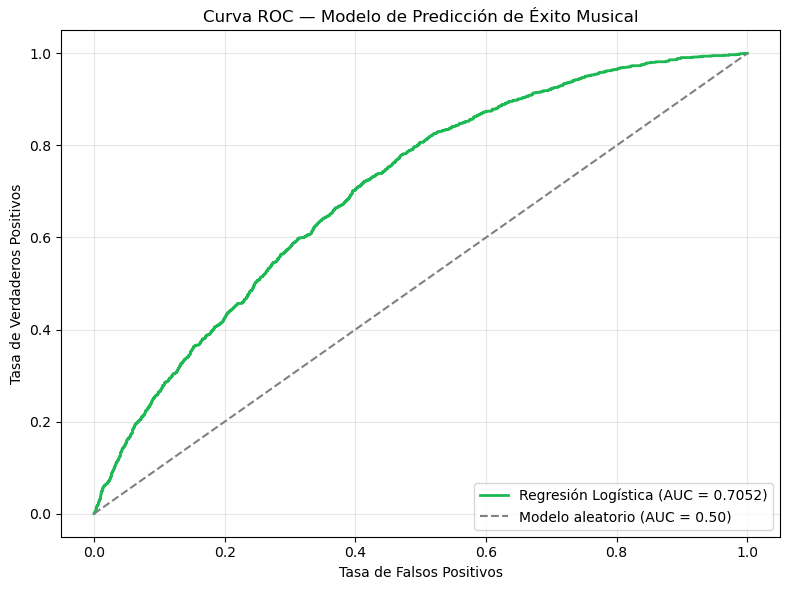

In [9]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#1DB954', linewidth=2,
         label=f'Regresión Logística (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--',
         label='Modelo aleatorio (AUC = 0.50)')
plt.title('Curva ROC — Modelo de Predicción de Éxito Musical')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Importancia de variables: coeficientes del modelo

Como todas las variables están ahora en la misma escala (media 0, desviación 1), la magnitud de los coeficientes sí es comparable entre sí: un coeficiente más grande en valor absoluto indica una variable con más peso en la predicción. 

=== Coeficientes del modelo (variables estandarizadas) ===
                      variable  coeficiente
                      loudness     0.483233
              energia_bailable     0.238597
                      explicit     0.170365
               cluster_Ambient     0.066854
           cluster_Pop y Dance     0.025209
                  n_artistas_4     0.024068
           cluster_Spoken Word     0.018728
                  danceability     0.011956
                 n_artistas_17     0.011784
                  n_artistas_8     0.009604
                  n_artistas_3     0.001908
                 n_artistas_31     0.000000
 cluster_Conciertos y Directos    -0.001908
                  n_artistas_2    -0.004382
                 n_artistas_32    -0.016269
                 n_artistas_26    -0.018725
                 n_artistas_19    -0.020684
                 n_artistas_38    -0.022192
                 n_artistas_22    -0.022456
                 n_artistas_20    -0.024183
                 

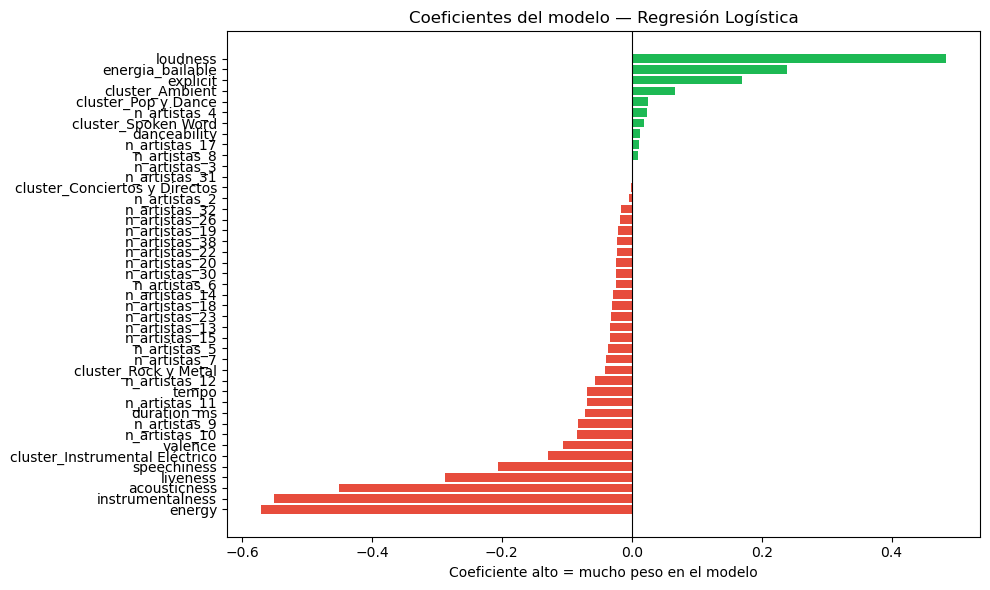

In [14]:
coeficientes = pd.DataFrame({
    'variable': X_train.columns,
    'coeficiente': modelo.coef_[0]
}).sort_values('coeficiente', ascending=False)

print("=== Coeficientes del modelo (variables estandarizadas) ===")
print(coeficientes.to_string(index=False))

plt.figure(figsize=(10, 6))
colores = ['#1DB954' if c > 0 else '#E74C3C' for c in coeficientes['coeficiente']]
plt.barh(coeficientes['variable'], coeficientes['coeficiente'], color=colores)
plt.title('Coeficientes del modelo — Regresión Logística')
plt.xlabel('Coeficiente alto = mucho peso en el modelo')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [110]:
# ── Exportación del dataset para Power BI ──────────────────────
# Reunimos en un solo CSV todo lo que el dashboard necesita.

# Partimos del dataset con clusters ya asignados
df_bi = data.copy()

# Añadimos la predicción del modelo a TODO el dataset
# (escalamos con el mismo scaler ya ajustado en train)
X_full = scaler.transform(df_bi[cols_modelo].astype('float64'))
df_bi['prediccion_exito'] = modelo.predict(X_full)
df_bi['probabilidad_exito'] = modelo.predict_proba(X_full)[:, 1].round(4)

# Seleccionamos solo las columnas útiles para el dashboard
cols_bi = ['track_name', 'artists', 'track_genre', 'popularity',
           'exito_musical', 'prediccion_exito', 'probabilidad_exito',
           'cluster', 'cluster_nombre',
           'danceability', 'energy', 'valence', 'acousticness',
           'instrumentalness', 'liveness', 'speechiness', 'loudness', 'tempo']

# Nos quedamos solo con las que existan (por si falta alguna)
cols_bi = [c for c in cols_bi if c in df_bi.columns]

df_bi[cols_bi].to_csv('spotify_powerbi.csv', index=False, encoding='utf-8-sig')
print(f"CSV exportado para Power BI: {df_bi[cols_bi].shape}")
print(f"Columnas: {cols_bi}")

c:\Users\souto\miniconda3\envs\env311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\souto\miniconda3\envs\env311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


CSV exportado para Power BI: (113549, 18)
Columnas: ['track_name', 'artists', 'track_genre', 'popularity', 'exito_musical', 'prediccion_exito', 'probabilidad_exito', 'cluster', 'cluster_nombre', 'danceability', 'energy', 'valence', 'acousticness', 'instrumentalness', 'liveness', 'speechiness', 'loudness', 'tempo']
